# Detect human faces

Python code to detect the region(s) of a image with human face(s). This region can be used for classification with additional image procssing.

## Import libraries

In [141]:
import imutils
import numpy as np
import cv2

from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import skimage.io as io

## Load image

In [142]:
# Select one image from coco dataset
dataDir= '../4 - Yolo Detection'
dataType='val2017'
annFile='{}/annotations/instances_{}.json'.format(dataDir,dataType)
print(annFile)

# initialize COCO api for instance annotations
coco=COCO(annFile)

# get all images Id containing given categories, select the first one
category_Ids = coco.getCatIds(catNms=['person'])
imgIds = coco.getImgIds(catIds = category_Ids )
# Load the 121th image
imgIds = coco.getImgIds(imgIds = imgIds[120]) # works
#imgIds = coco.getImgIds(imgIds = imgIds[124]) # Do not work
img = coco.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]
print('Image URL:', img['coco_url']) # url for the coco image

../4 - Yolo Detection/annotations/instances_val2017.json
loading annotations into memory...
Done (t=0.49s)
creating index...
index created!
Image URL: http://images.cocodataset.org/val2017/000000131444.jpg


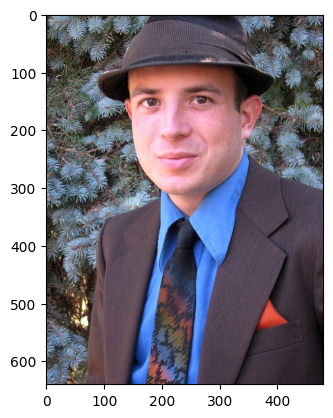

original shape 480 640


In [ ]:
# load and display image
# I = io.imread('%s/images/%s/%s'%(dataDir,dataType,img['file_name']))
# use url to load image
I = io.imread(img['coco_url'])
#plt.axis('off')
plt.imshow(I)
plt.show()
(h, w) = I.shape[:2]
print('original shape', w,h)

new shape 400 533


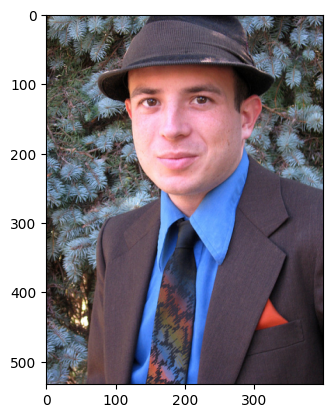

In [170]:
# Reshape image to 400 pixels
image = imutils.resize(I, width=400)
(h, w) = image.shape[:2]
print('new shape', w,h)
#plt.axis('off')
plt.imshow(image)
plt.show()

## Load Model
Load pre-trained model for face detections. The model has 2 files:
- Model definition (deploy.prototxt) (https://github.com/opencv/opencv/blob/4.x/samples/dnn/face_detector/deploy.prototxt)
- Weights from pre-training (res10_300x300_ssd_iter_140000.caffemodel)(https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20180205_fp16/res10_300x300_ssd_iter_140000_fp16.caffemodel)

The OpenCV Deep Learning face detector is based on the Single Shot Detector (SSD) framework with a ResNet base network. The network is defined and trained using the Caffe Deep Learning framework.

In [151]:
print("[INFO] loading model...")
prototxt = 'model/deploy.prototxt'
model = 'model/res10_300x300_ssd_iter_140000_fp16.caffemodel'
net = cv2.dnn.readNetFromCaffe(prototxt, model)

[INFO] loading model...


## Make Blob
Construct an input blob by resizing the image to a fixed 300x300 pixels and normalizing it.

In [171]:
# redimensiona para ter uma largura máxima de 400 pixels
image = imutils.resize(image, width=400)
blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

## Run Face Detection model

In [172]:
print("[INFO] computing object detections...")
net.setInput(blob)
detections = net.forward()

[INFO] computing object detections...


In [173]:
# Iterate the detections and draw boxes around the detected faces (if confidence is > 0.5).
for i in range(0, detections.shape[2]):

	# extrair a probabilidade associada à previsão
	confidence = detections[0, 0, i, 2]

	# filtra detecções fracas garantindo que a "confiança" seja
	# maior que o limite mínimo de confiança
	if confidence > 0.5: #Nossa detecção deve ter no mínimo 50% de certeza
		# calcula as coordenadas (x, y) da caixa delimitadora do objeto
		box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
		(startX, startY, endX, endY) = box.astype("int")
		# desenha a caixa delimitadora da face junto com a probabilidade associada
		text = "{:.2f}%".format(confidence * 100)
		y = startY - 10 if startY - 10 > 10 else startY + 10
		cv2.rectangle(image, (startX, startY), (endX, endY), (0, 0, 255), 2)
		cv2.putText(image, text, (startX, y),
			cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)

Show the resulting image

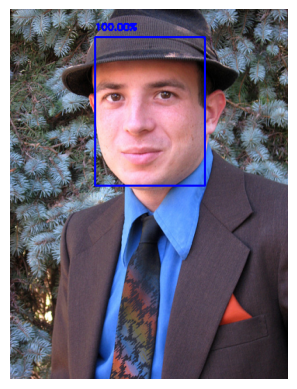

In [174]:
# use url to load image
plt.axis('off')
plt.imshow(image)
plt.show()